In [17]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import iterate
importlib.reload(iterate)
from iterate import bifurcation_points, BETA
from hassel_newton import newton_super_stable

np.set_printoptions(suppress=True)

In [11]:
zero_thirty = bifurcation_points(0, 30, 0.01)

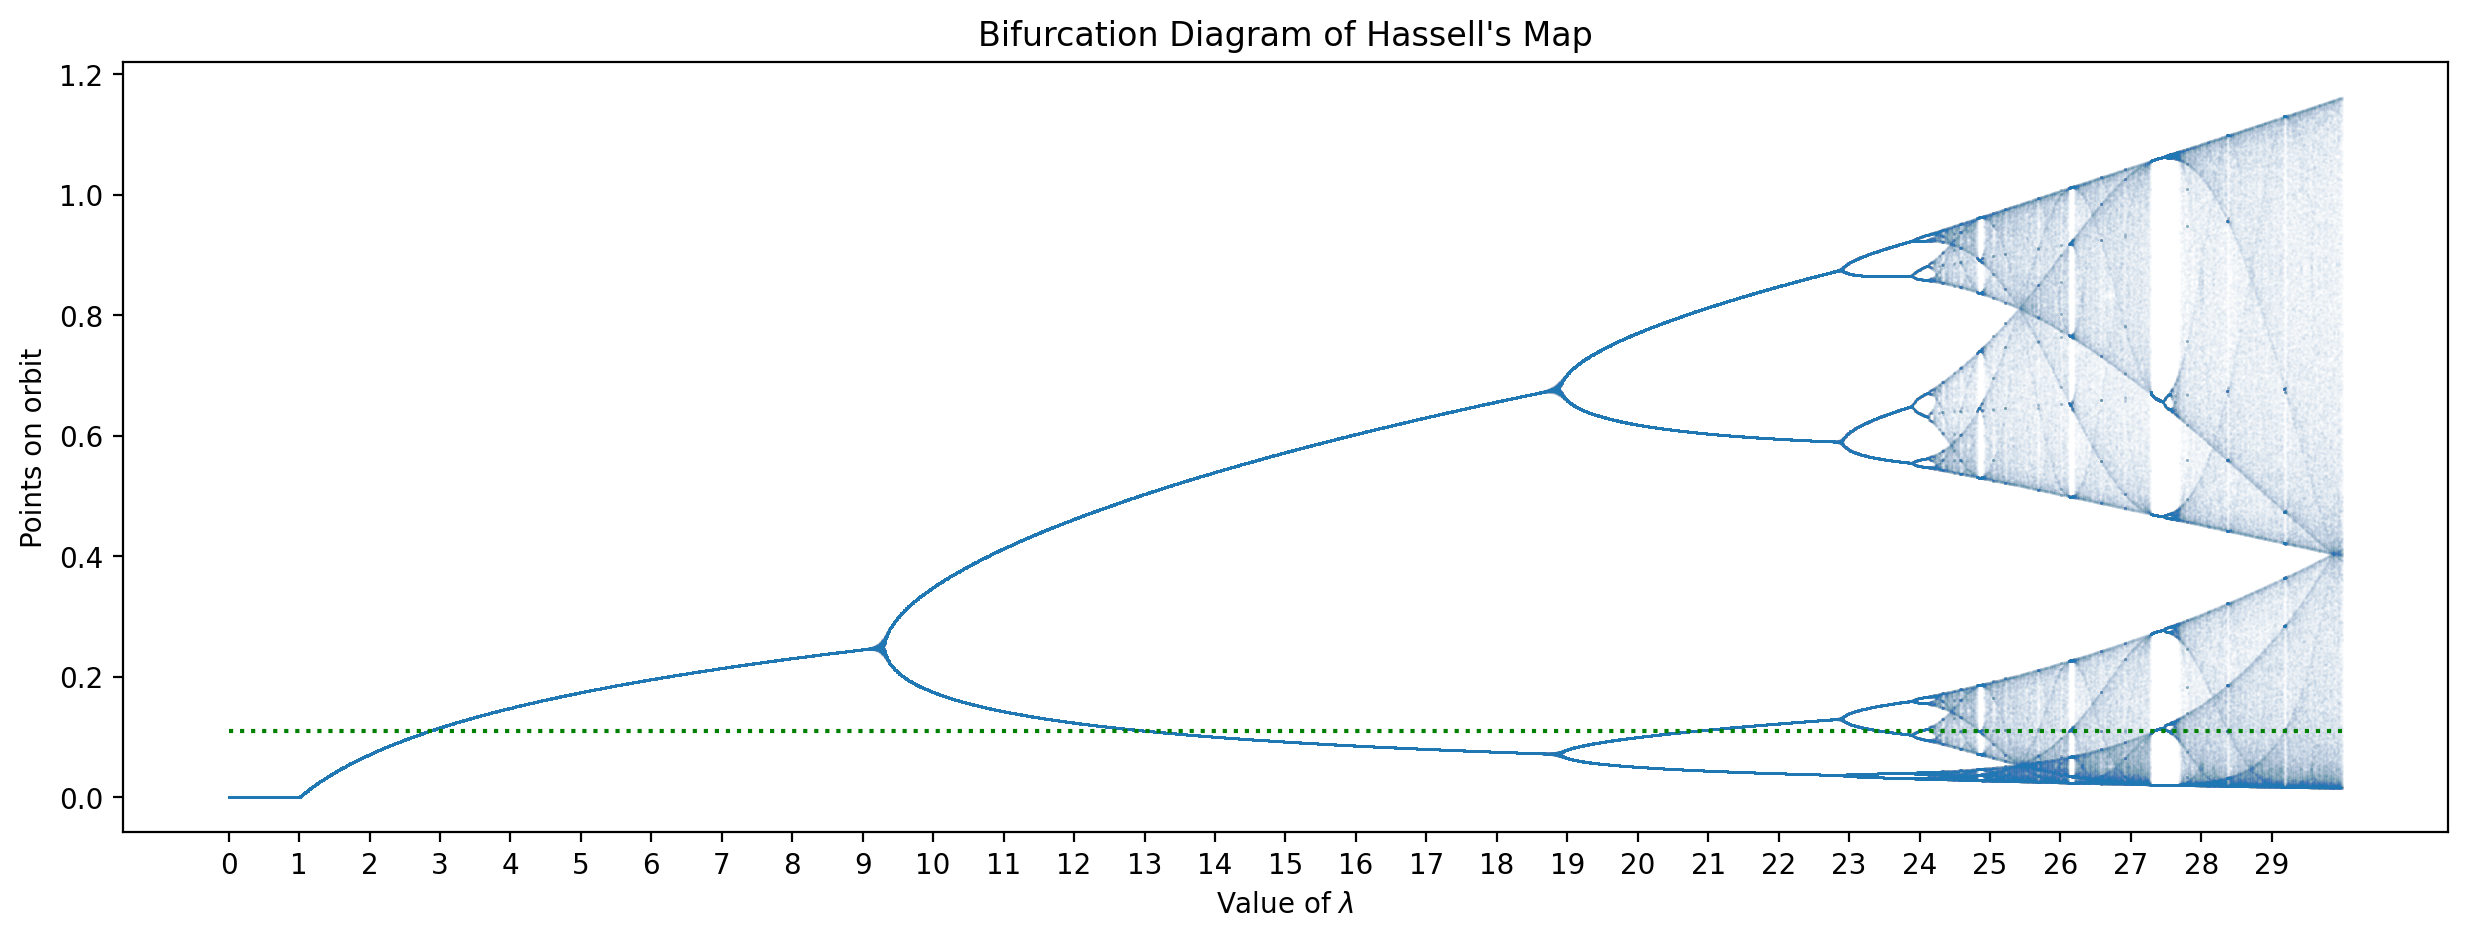

In [14]:
plt.figure(figsize=(15, 5), dpi=200)
sns.scatterplot(x=zero_thirty[0], y=zero_thirty[1], alpha=0.01, s=1)
plt.title("Bifurcation Diagram of Hassell's Map")
plt.xticks(np.arange(0, 30, 1))
plt.xlabel("Value of $\lambda$")
plt.ylabel("Points on orbit")
plt.hlines(1/9, 0, 30, colors="green", linestyles="dotted")
plt.show()

In [18]:
sks = [2.86, 12.99, newton_super_stable(3, 20.89, BETA)]
f_consts = [4]
print(f"S3 = {sks[-1]}, f3 = {f_consts[-1]})")

for i in range(4, 11):
    diff = sks[-1] - sks[-2]
    new_guess = sks[-1] + (diff) / f_consts[-1]
    sks.append(newton_super_stable(i, new_guess, BETA))
    f_consts.append((sks[-3] - sks[-2]) / (sks[-2] - sks[-1]))
    print(f"S{i} = {sks[-1]}, diff={diff}, f{i} = {f_consts[-1]}")

figenbaum_pt = sks[-1] + (sks[-1] - sks[-2]) / (f_consts[-1] - 1)
print(f"Accumulation point: {figenbaum_pt}")

S3 = 20.866694236673098, f3 = 4)
S4 = 23.419637371147658, diff=7.876694236673098, f4 = 3.085338694116372
S5 = 24.01926662982543, diff=2.5529431344745603, f5 = 4.257535964979412
S6 = 24.150402535294052, diff=0.5996292586777727, f6 = 4.572578780273521
S7 = 24.178611790423023, diff=0.13113590546862142, f7 = 4.648683734082205
S8 = 24.184659128852765, diff=0.028209255128970767, f8 = 4.664738951971581
S9 = 24.18595454692781, diff=0.0060473384297417, f9 = 4.668252316557503
S10 = 24.186231997944134, diff=0.001295418075045518, f10 = 4.668997404338863
Accumulation point: 24.186307618334595


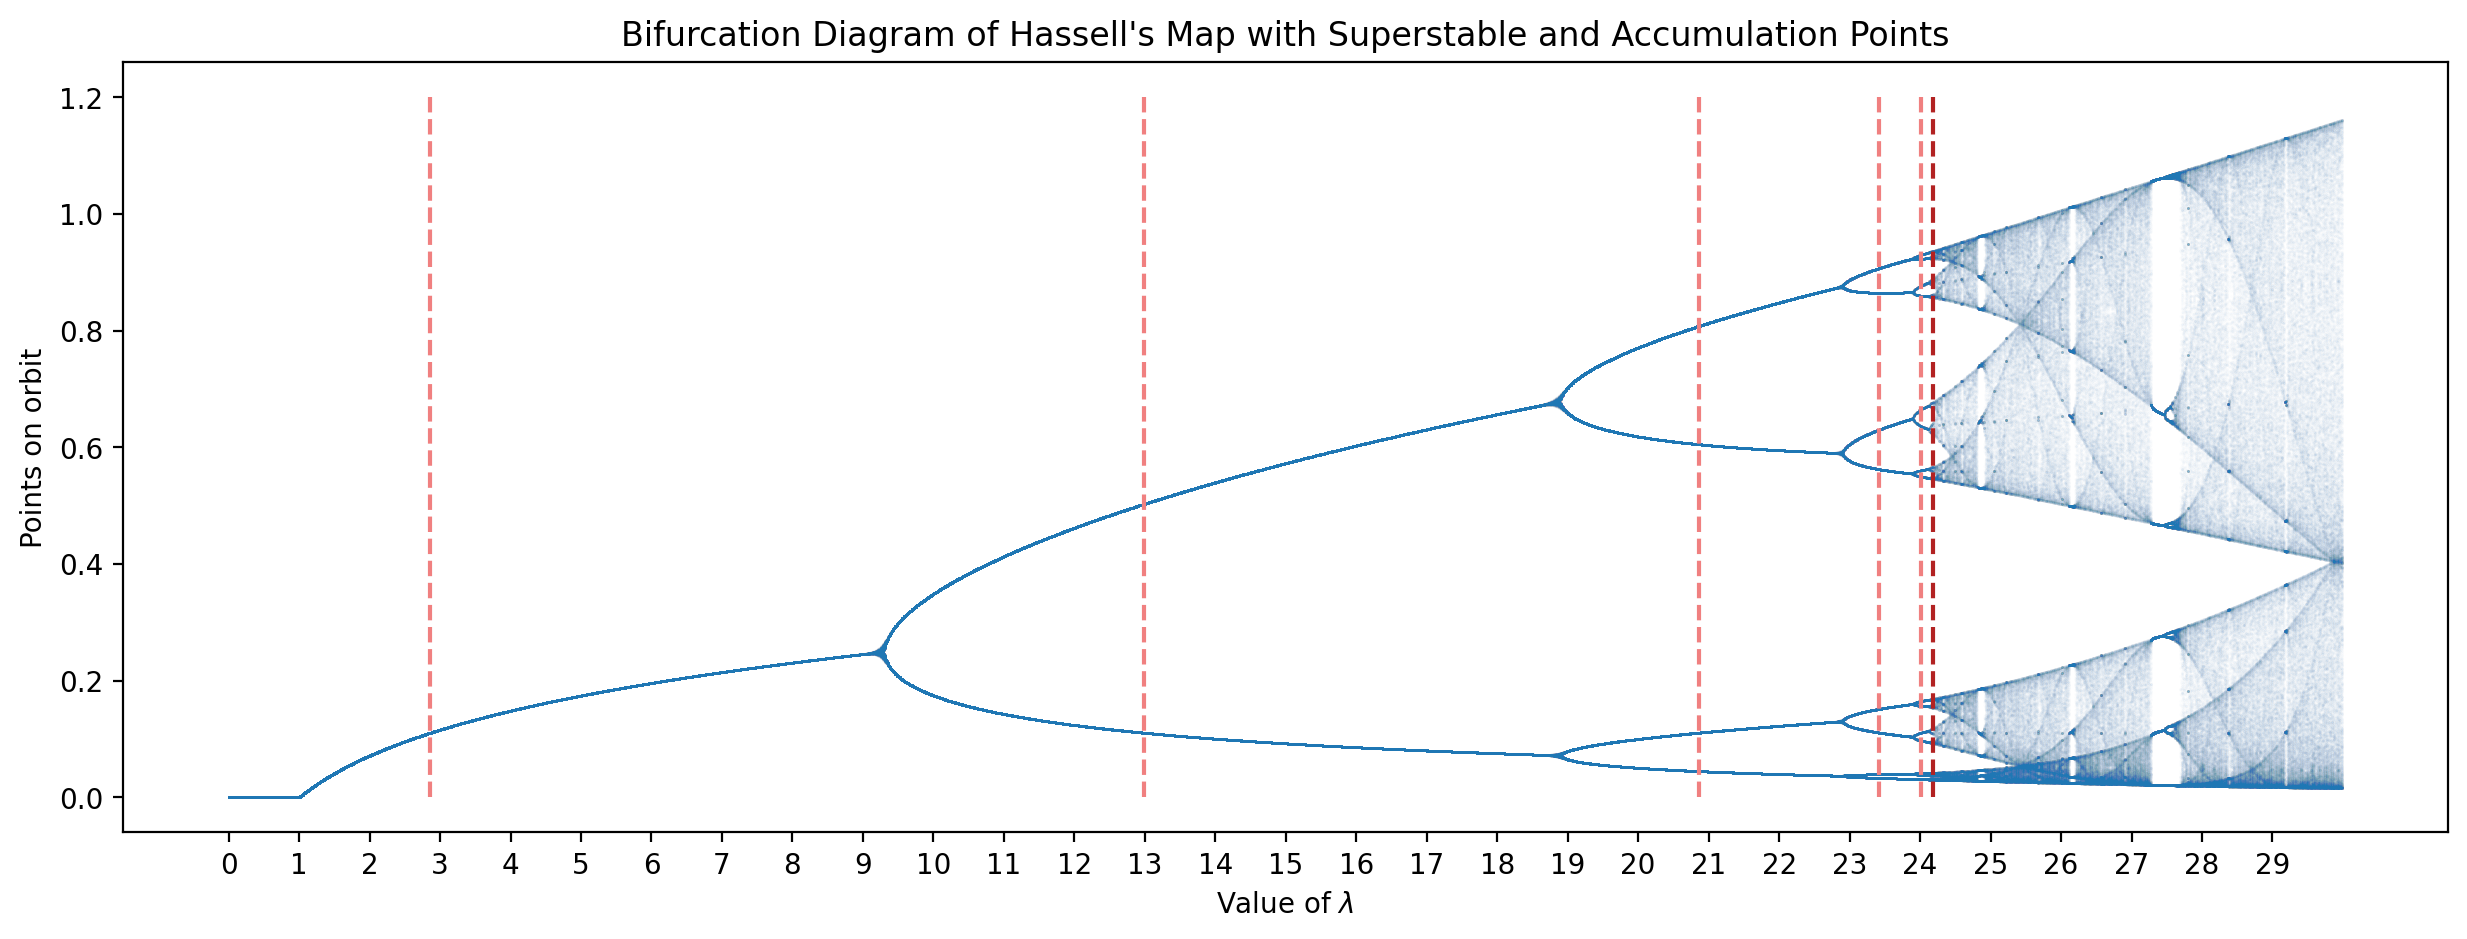

In [23]:
plt.figure(figsize=(15, 5), dpi=200)
sns.scatterplot(x=zero_thirty[0], y=zero_thirty[1], alpha=0.01, s=1)
plt.title("Bifurcation Diagram of Hassell's Map with Superstable and Accumulation Points")
plt.xticks(np.arange(0, 30, 1))
plt.xlabel("Value of $\lambda$")
plt.ylabel("Points on orbit")
# plt.hlines(1/9, 0, 30, colors="green", linestyles="dotted")
plt.vlines(sks[0:5], 0, 1.2, colors="lightcoral", linestyles="dashed")
plt.vlines(figenbaum_pt, 0, 1.2, colors="firebrick", linestyles="dashed")
plt.show()